In [1]:
import pandas as pd
import joblib

X_train = pd.read_parquet("../data/processed/X_train.parquet")
X_test = pd.read_parquet("../data/processed/X_test.parquet")
y_train = pd.read_parquet("../data/processed/y_train.parquet")['Churn']
y_test = pd.read_parquet("../data/processed/y_test.parquet")['Churn']
preprocessor = joblib.load("../data/processed/preprocessor.joblib")

## Model Comparison - LogisticRegression vs RandomForest Classifier

Baseline comparison of both models ('class_weight='balanced', from previous decision) using 5-folds `StratifiedKFold` cross-validation on the training set. F1 and recall (minority class) are tracked

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42))
])

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logreg_scores = cross_validate(logreg_pipeline, X_train, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], return_train_score=True)

rf_scores = cross_validate(rf_pipeline, X_train, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], return_train_score=True)

In [4]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [logreg_scores['test_accuracy'].mean(), rf_scores['test_accuracy'].mean()],
    'Precision': [logreg_scores['test_precision'].mean(), rf_scores['test_precision'].mean()],
    'Recall': [logreg_scores['test_recall'].mean(), rf_scores['test_recall'].mean()],
    'F1-Score': [logreg_scores['test_f1'].mean(), rf_scores['test_f1'].mean()]
})

print(comparison_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.749914   0.518611  0.803344  0.630239
1        Random Forest  0.790916   0.646413  0.469565  0.543921


**Findings:** LogisticRegression catches 80% of churners; RandomForest catches 47%. That's the number that decides this, a missed churner causes no chance of intervention, so recall matters more so than accuracy or precision RandomForest wins on (79.1% vs 75.0% accuracy, 0.646 vs 0.519 precision). F1 actually favors RandomForest (0.544 vs 0.630 for LogReg), but F1 is the wrong lens here as it rewards a precision/recall balance this problem doesn't need.

The gap probably comes down to how `class_weight='balanced'` hits each model differently. LogisticRegression reweights the loss directly, so it's a strong, blunt push toward flagging minority-class rows. RandomForest reweights impurity at each split instead, and that effect thins out once you're averaging votes across 100 trees. Neither model is tuned yet, so this isn't the two algorithms at their best but at default setting up

**Decision:** LogisticRegression is the model going forward. RandomForest stays on the
bench. If tuning LogReg stalls, or if false positives start costing more than assumed,
it's the first thing to revisit.

## Hyperparameter Tuning

Tuned LogisticRegression's `C`, `penalty`, and `solver` with `GridSearchCV`, same 5-fold `StratifiedKFold` as Step 6, scoring on recall per the Step 4 decision. `lbfgs` only supports `l2`, so the grid split into two subspaces (`lbfgs`+`l2`, and `liblinear`/`saga`+`l1`/`l2`). 25 valid combos total — small enough to search exhaustively instead of sampling.

In [5]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_distributions = [
    {
        "classifier__solver": ["lbfgs"],
        "classifier__penalty": ["l2"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "classifier__solver": ["liblinear", "saga"],
        "classifier__penalty": ["l1", "l2"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
    },
]

In [6]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    logreg_pipeline,
    param_grid=param_distributions,
    cv=cv,
    scoring="recall",
    return_train_score=True,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
0.8127090301003344


In [7]:
tuned_scores = cross_validate(
    grid_search.best_estimator_, 
    X_train, 
    y_train, 
    cv=cv, 
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], 
    return_train_score=True
)

print({k: v.mean() for k, v in tuned_scores.items() if 'test_' in k})

grid_search.best_estimator_.named_steps['classifier'].coef_

{'test_accuracy': np.float64(0.7518673729434626), 'test_precision': np.float64(0.5210822748457613), 'test_recall': np.float64(0.8127090301003344), 'test_f1': np.float64(0.6349150415824765), 'test_roc_auc': np.float64(0.8508059995728088)}


array([[-5.01202525e-01,  3.84336084e-01, -2.74523586e-02,
         3.74296231e-01,  0.00000000e+00,  0.00000000e+00,
         1.35075646e-01,  0.00000000e+00, -1.49845478e-01,
        -5.57565959e-01,  0.00000000e+00,  2.16387563e-01,
         5.93842512e-01, -1.56626498e-04, -2.78919333e-04,
        -3.67848747e-01, -1.20551554e-03, -1.19316473e-01,
        -4.23966033e-04,  0.00000000e+00, -2.16410994e-04,
        -2.92063650e-01, -1.17237133e-05,  1.41540725e-01,
        -5.25929728e-01,  1.56254908e-01, -6.42921165e-01,
        -1.42822711e+00,  3.23827775e-01,  0.00000000e+00,
         3.80509950e-01,  0.00000000e+00,  0.00000000e+00,
        -2.08584337e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00]])

Best params: `C=0.1`, `penalty='l1'`, `solver='liblinear'`.

| Metric | Step 6 baseline | Tuned |
|---|---|---|
| Accuracy | 0.750 | 0.752 |
| Precision | 0.519 | 0.521 |
| Recall | 0.803 | 0.813 |
| F1 | 0.630 | 0.635 |

All four metrics improved, not just recall. Train and test scores are close on every metric (recall 0.813 both), so the regularization isn't over- or under-fitting.

In [8]:
feature_names = grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
coefs = grid_search.best_estimator_.named_steps['classifier'].coef_[0]
pd.Series(coefs, index=feature_names).sort_values()

cat__Contract_Two year                       -1.428227
cat__Contract_One year                       -0.642921
cat__PhoneService_Yes                        -0.557566
cat__StreamingMovies_No internet service     -0.525930
num__tenure                                  -0.501203
cat__OnlineSecurity_Yes                      -0.367849
cat__TechSupport_Yes                         -0.292064
cat__tenure_bucket_24-35                     -0.208584
cat__Dependents_Yes                          -0.149845
cat__OnlineBackup_Yes                        -0.119316
num__TotalCharges                            -0.027452
cat__OnlineBackup_No internet service        -0.001206
cat__DeviceProtection_No internet service    -0.000424
cat__OnlineSecurity_No internet service      -0.000279
cat__TechSupport_No internet service         -0.000216
cat__InternetService_No                      -0.000157
cat__StreamingTV_No internet service         -0.000012
cat__tenure_bucket_36-47                      0.000000
cat__tenur

`l1` zeroed 11 of 37 coefficients, including two of six `..._No internet service` dummies (`DeviceProtection`, `StreamingMovies`). Those six columns duplicate each other, all flip to 1 together when a customer has no internet service, so `l1` collapsed real redundancy, not just weak signal.

Largest coefficients: `Contract_Two year` (-1.43), `Contract_One year` (-0.64), `tenure` (-0.50), `InternetService_Fiber optic` (+0.59). Contract length dominates the model.

**Decision:** tuned LogisticRegression (`C=0.1`, `l1`, `liblinear`) replaces the Step 6 baseline. RandomForest stays the untuned fallback.

## Boosting Comparison (XGBoost)

Benchmarks are gradient-boosted tree model against the LogisticRegressiona and RandomForest using the same `StratifiedKFold` CV and scoring set

**Class Weighting:** LogisticRegression and RandomForest use `class_weight='balanced'`, but XGBoost doesn't use `class_weight`. The equivalent is instead `scale_pos_weight = n_negative / n_positive`, made using `y_train`

The tuned LogisticRegression models will remain primary model unless XGBoost model, beats it on **both recall and ROC-AUC** in the cross-validation. RandomForest stays the fallback option if needed.



In [9]:
from xgboost import XGBClassifier

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=scale_pos_weight, 
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1,
    ))
])


In [10]:
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

xgb_scores = cross_validate(xgb_pipeline, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)

print({k: v.mean() for k, v in xgb_scores.items() if 'test_' in k})

{'test_accuracy': np.float64(0.7703245542560216), 'test_precision': np.float64(0.5562861499481218), 'test_recall': np.float64(0.6642140468227424), 'test_f1': np.float64(0.6054372811933525), 'test_roc_auc': np.float64(0.8221208370861044)}


In [11]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression (tuned)', 'Random Forest', 'XGBoost'],
    'Accuracy':  [tuned_scores['test_accuracy'].mean(),  rf_scores['test_accuracy'].mean(),  xgb_scores['test_accuracy'].mean()],
    'Precision': [tuned_scores['test_precision'].mean(), rf_scores['test_precision'].mean(), xgb_scores['test_precision'].mean()],
    'Recall':    [tuned_scores['test_recall'].mean(),    rf_scores['test_recall'].mean(),    xgb_scores['test_recall'].mean()],
    'F1-Score':  [tuned_scores['test_f1'].mean(),        rf_scores['test_f1'].mean(),        xgb_scores['test_f1'].mean()],
    'ROC-AUC':   [tuned_scores['test_roc_auc'].mean(),   rf_scores['test_roc_auc'].mean(),   xgb_scores['test_roc_auc'].mean()],
})
print(comparison_df)

                         Model  Accuracy  ...  F1-Score   ROC-AUC
0  Logistic Regression (tuned)  0.751867  ...  0.634915  0.850806
1                Random Forest  0.790916  ...  0.543921  0.824984
2                      XGBoost  0.770325  ...  0.605437  0.822121

[3 rows x 6 columns]


In [12]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_distributions = {
    "classifier__n_estimators":     [100, 200, 400, 600],
    "classifier__learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "classifier__max_depth":        [3, 4, 5, 6],
    "classifier__subsample":        [0.7, 0.85, 1.0],
    "classifier__colsample_bytree": [0.7, 0.85, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_distributions,
    n_iter=20,
    cv=cv,
    scoring='recall',          # consistent with Step 4
    random_state=42,
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train)
print(xgb_search.best_params_)
print(xgb_search.best_score_)

# full metric set on the tuned booster, same as the other models
xgb_tuned_scores = cross_validate(
    xgb_search.best_estimator_, X_train, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True
)
print({k: v.mean() for k, v in xgb_tuned_scores.items() if k.startswith('test_')})

{'classifier__subsample': 0.85, 'classifier__n_estimators': 200, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 1.0}
0.8080267558528428
{'test_accuracy': np.float64(0.7429920520219826), 'test_precision': np.float64(0.509963305074404), 'test_recall': np.float64(0.8107023411371237), 'test_f1': np.float64(0.6260539758669037), 'test_roc_auc': np.float64(0.8465299555180762)}


**Findings:** Baseline XGBoost (`scale_pos_weight`, otherwise default) landed at recall
0.664 / ROC-AUC 0.822, well behind the tuned LogisticRegression. A 20-iteration
`RandomizedSearchCV` on recall closed the recall gap (0.664 -> 0.811) but produced no
metric that beats tuned LogReg: recall 0.811 vs 0.813, ROC-AUC 0.847 vs 0.851,
precision 0.510 vs 0.521, F1 0.626 vs 0.635, accuracy 0.743 vs 0.752.

The tuned booster's best config, `learning_rate=0.01`, `max_depth=4`,
`n_estimators=200`, is a shallow, strongly regularised model, i.e. the search drove
XGBoost toward a near-linear decision boundary to match the linear model rather than
finding extra non-linear signal.

**Decision:** tuned LogisticRegression (`C=0.1`, `l1`, `liblinear`) remains the primary
model. It is not beaten on any metric, and it is the model whose coefficients are
directly interpretable for the business narrative. RandomForest and XGBoost stay
as alternatives.

## Test Set Evaluation

Evaluation on `X_test` / `y_test`. The model in use will be the tuned LogisticRegression which was refit with the full training set by `GridSearchCV(refit=True)`. RandomForest and XGBoost will not be evaluated here since they are alternatives.

In [13]:
champion = grid_search.best_estimator_

y_pred = champion.predict(X_test)
y_proba = champion.predict_proba(X_test)[:, 1]

TN=737, FP=298, FN=74, TP=300
Churners missed (FN): 74 of 374
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



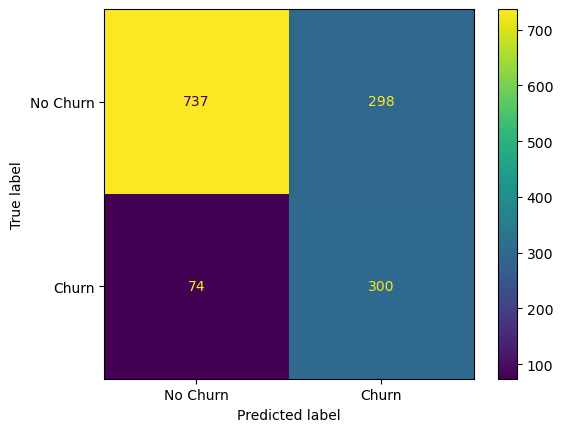

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Churn', 'Churn'])

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Churners missed (FN): {fn} of {fn + tp}")

print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Test ROC-AUC: 0.8491    (CV:0.851)


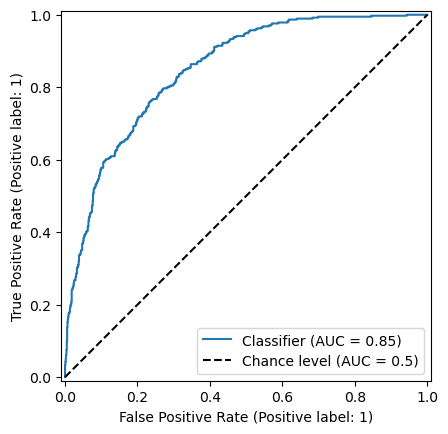

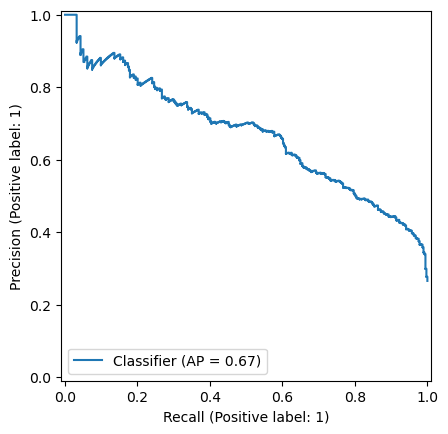

In [16]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay

test_auc = roc_auc_score(y_test, y_proba)
print(f"Test ROC-AUC: {test_auc:.4f}    (CV:0.851)")

RocCurveDisplay.from_predictions(y_test, y_proba, plot_chance_level=True)
PrecisionRecallDisplay.from_predictions(y_test, y_proba)

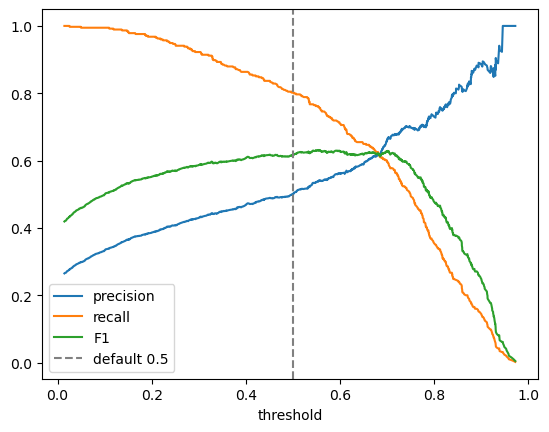

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

plt.plot(thresholds, precision[:-1], label='precision')
plt.plot(thresholds, recall[:-1], label='recall')
plt.plot(thresholds, f1_scores[:-1], label='F1')
plt.axvline(0.5, color='grey', linestyle='--', label='default 0.5')
plt.xlabel('threshold'); plt.legend()
plt.show()



**Findings:** Test-set performance matches cross-validation closely,recall 0.802
(CV 0.813), ROC-AUC 0.849 (CV 0.851), precision 0.502 (CV 0.521). Every metric is
within ~2 points of its CV estimate, so the model is not overfit and the CV numbers
were a reliable guide.

Confusion matrix: TP=300, FN=74, FP=298, TN=737. The model catches 300 of 374 churners
(80.2%) and misses 74. The cost is 298 false positives out of 1035 non-churners
(28.8% false-positive rate).

Threshold: at the default 0.5 the model sits at recall 0.80 / precision 0.50.